In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

## Load processed metadata

In [2]:
PROJECT_ROOT = Path("..")

cd4 = pd.read_csv(
    PROJECT_ROOT / "data/processed/cd4_metadata.csv"
)

cd14 = pd.read_csv(
    PROJECT_ROOT / "data/processed/cd14_metadata.csv"
)

## Initial inspection

In [3]:
print("CD4:", cd4.shape)
print("CD14:", cd14.shape)

display(cd4.head())
display(cd14.head())

CD4: (499, 14)
CD14: (485, 14)


,geo_accession,sample_title,individual_id,sample_code,cell_type,replicate,age,sex,cell_type_description,batch,inclusion_markers,exclusion_markers,phenotype_markers,separation_method
0,GSM1350856,IGTB10.4 [CD4],IGTB10,4,CD4,primary,30,Female,T4 Naive cells from human peripheral blood mon...,1,CD3+ CD4+ CD62L+,CD14- CD8- CD25-,CD3+ CD14- CD4+ CD8- CD62L+ CD25-,Aria Sorter
1,GSM1350857,IGTB10.4BR1 [CD4],IGTB10,4,CD4,BR1,30,Female,T4 Naive cells from human peripheral blood mon...,1,CD3+ CD4+ CD62L+,CD14- CD8- CD25-,CD3+ CD14- CD4+ CD8- CD62L+ CD25-,Aria Sorter
2,GSM1350858,IGTB100.4 [CD4],IGTB100,4,CD4,primary,47,Male,T4 Naive cells from human peripheral blood mon...,1,CD3+ CD4+ CD62L+,CD14- CD8- CD25-,CD3+ CD14- CD4+ CD8- CD62L+ CD25-,Aria Sorter
3,GSM1350859,IGTB1004.4 [CD4],IGTB1004,4,CD4,primary,46,Female,T4 Naive cells from human peripheral blood mon...,4,CD3+ CD4+ CD62L+,CD14- CD8- CD25-,CD3+ CD14- CD4+ CD8- CD62L+ CD25-,Aria Sorter
4,GSM1350860,IGTB1007.4 [CD4],IGTB1007,4,CD4,primary,42,Male,T4 Naive cells from human peripheral blood mon...,1,CD3+ CD4+ CD62L+,CD14- CD8- CD25-,CD3+ CD14- CD4+ CD8- CD62L+ CD25-,Aria Sorter


,geo_accession,sample_title,individual_id,sample_code,cell_type,replicate,age,sex,cell_type_description,batch,inclusion_markers,exclusion_markers,phenotype_markers,separation_method
0,GSM1351309,IGTB3.14,IGTB3,14,CD14,primary,32,Female,monocytes from peripheral blood mononuclear ce...,1,CD14+,CD3- CD16-,CD3- CD14+ CD16-,Aria Sorter
1,GSM1351310,IGTB4.F14TR1,IGTB4,F14,CD14,TR1,54,Female,monocytes from peripheral blood mononuclear ce...,5,CD14+,CD3- CD16-,CD3- CD14+ CD16-,Aria Sorter
2,GSM1351311,IGTB4.F14TR2,IGTB4,F14,CD14,TR2,54,Female,monocytes from peripheral blood mononuclear ce...,5,CD14+,CD3- CD16-,CD3- CD14+ CD16-,Aria Sorter
3,GSM1351312,IGTB4.14,IGTB4,14,CD14,primary,53,Female,monocytes from peripheral blood mononuclear ce...,1,CD14+,CD3- CD16-,CD3- CD14+ CD16-,Aria Sorter
4,GSM1351313,IGTB8.14,IGTB8,14,CD14,primary,34,Female,monocytes from peripheral blood mononuclear ce...,1,CD14+,CD3- CD16-,CD3- CD14+ CD16-,Aria Sorter


In [4]:
cd4.info()
cd14.info()

<class 'pandas.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   geo_accession          499 non-null    str  
 1   sample_title           499 non-null    str  
 2   individual_id          499 non-null    str  
 3   sample_code            499 non-null    str  
 4   cell_type              499 non-null    str  
 5   replicate              499 non-null    str  
 6   age                    499 non-null    int64
 7   sex                    499 non-null    str  
 8   cell_type_description  499 non-null    str  
 9   batch                  499 non-null    int64
 10  inclusion_markers      499 non-null    str  
 11  exclusion_markers      499 non-null    str  
 12  phenotype_markers      499 non-null    str  
 13  separation_method      499 non-null    str  
dtypes: int64(2), str(12)
memory usage: 54.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 485 entries, 0 to 4

In [5]:
cd4.nunique().sort_values()

cell_type                  1
cell_type_description      1
inclusion_markers          1
exclusion_markers          1
phenotype_markers          1
separation_method          1
sex                        2
sample_code                6
replicate                  6
batch                      6
age                       39
individual_id            454
geo_accession            499
sample_title             499
dtype: int64

In [6]:
cd14.nunique().sort_values()

cell_type                  1
cell_type_description      1
inclusion_markers          1
exclusion_markers          1
phenotype_markers          1
separation_method          1
sample_code                2
sex                        2
replicate                  4
batch                      6
age                       37
individual_id            449
geo_accession            485
sample_title             485
dtype: int64

## Variable summaries

In [7]:
cd4["age"].describe()

count    499.000000
mean      30.032064
std        9.961118
min        9.000000
25%       22.000000
50%       27.000000
75%       36.000000
max       56.000000
Name: age, dtype: float64

Text(0, 0.5, 'Count')

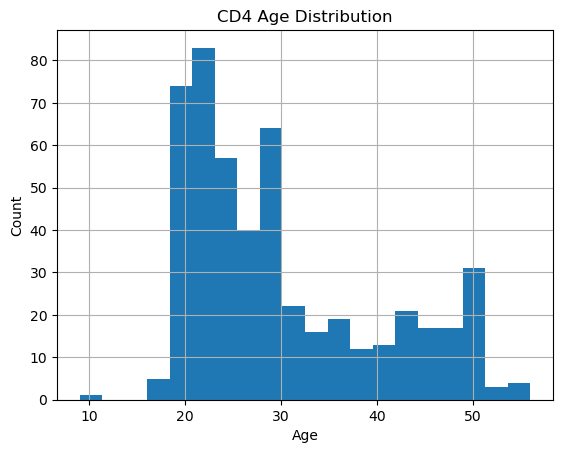

In [8]:
ax = cd4["age"].hist(bins=20)
ax.set_title("CD4 Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Count")

In [18]:
cd14["age"].describe()

count    485.000000
mean      30.441237
std       10.199819
min       18.000000
25%       22.000000
50%       27.000000
75%       38.000000
max       54.000000
Name: age, dtype: float64

Text(0, 0.5, 'Count')

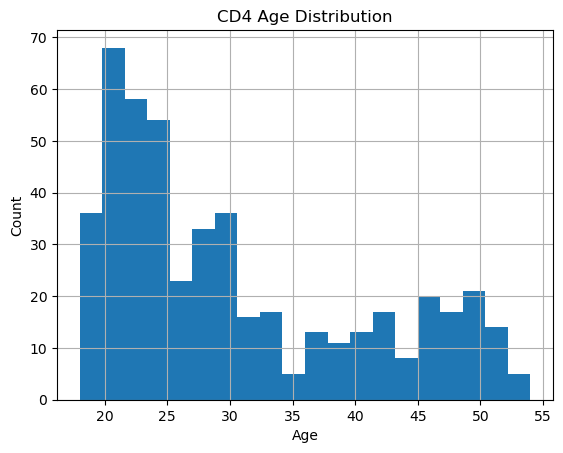

In [9]:
ax = cd14["age"].hist(bins=20)
ax.set_title("CD4 Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Count")

## Participant overlap

In [10]:
print("Unique CD4 individuals:", cd4["individual_id"].nunique())
print("Unique CD14 individuals:", cd14["individual_id"].nunique())

Unique CD4 individuals: 454
Unique CD14 individuals: 449


In [11]:
shared_individuals = set(cd4["individual_id"]) & set(cd14["individual_id"])

print("Individuals represented in both datasets:", len(shared_individuals))

Individuals represented in both datasets: 388


In [12]:
cd4_missing = cd4[~cd4["individual_id"].isin(shared_individuals)]
cd14_missing = cd14[~cd14["individual_id"].isin(shared_individuals)]

In [13]:
display(cd4_missing["replicate"].value_counts())
display(cd14_missing["replicate"].value_counts())

replicate
primary    65
TR1         3
TR2         3
BR1         1
Name: count, dtype: int64

replicate
primary    58
TR1         3
TR2         3
BR1         1
Name: count, dtype: int64

In [17]:
display(cd4_missing["sex"].value_counts())
display(cd14_missing["sex"].value_counts())

display(cd4_missing["age"].describe())
display(cd14_missing["age"].describe())

sex
Female    51
Male      21
Name: count, dtype: int64

sex
Female    36
Male      29
Name: count, dtype: int64

count    72.000000
mean     28.430556
std       8.704583
min      18.000000
25%      22.000000
50%      27.000000
75%      32.000000
max      56.000000
Name: age, dtype: float64

count    65.000000
mean     30.507692
std      10.643547
min      18.000000
25%      22.000000
50%      26.000000
75%      42.000000
max      51.000000
Name: age, dtype: float64

In [14]:
cd4_only = sorted(set(cd4["individual_id"]) - set(cd14["individual_id"]))
cd14_only = sorted(set(cd14["individual_id"]) - set(cd4["individual_id"]))

print(f"CD4 only: {len(cd4_only)}")
print(f"CD14 only: {len(cd14_only)}")

cd4_only[:10], cd14_only[:10]

CD4 only: 66
CD14 only: 61


(['IGTB1023',
  'IGTB111',
  'IGTB1112',
  'IGTB1157',
  'IGTB1162',
  'IGTB1171',
  'IGTB1192',
  'IGTB1223',
  'IGTB1224',
  'IGTB1255'],
 ['IGTB104',
  'IGTB1040',
  'IGTB1046',
  'IGTB1051',
  'IGTB1123',
  'IGTB1140',
  'IGTB1145',
  'IGTB1170',
  'IGTB1189',
  'IGTB1197'])

### Observations

- CD4 contains 454 unique individuals.
- CD14 contains 449 unique individuals.
- 388 individuals appear in both datasets.
- The remaining participants are unique to one cell type and should be investigated before paired analyses.


## Biological covariates

In [15]:
display(cd4["sex"].value_counts(dropna=False))
display(cd4["batch"].value_counts().sort_index())
display(cd4["replicate"].value_counts())

sex
Female    294
Male      205
Name: count, dtype: int64

batch
1     71
2     32
3     81
4    138
5    116
6     61
Name: count, dtype: int64

replicate
primary    458
BR1         13
TR1         13
TR2         13
TR3          1
TR4          1
Name: count, dtype: int64

In [16]:
display(cd14["sex"].value_counts(dropna=False))
display(cd14["batch"].value_counts().sort_index())
display(cd14["replicate"].value_counts())

sex
Female    272
Male      213
Name: count, dtype: int64

batch
1     83
2     31
3     98
4    122
5     91
6     60
Name: count, dtype: int64

replicate
primary    446
TR1         14
TR2         14
BR1         11
Name: count, dtype: int64